<a href="https://colab.research.google.com/github/Dinithiii04/AgriLak/blob/yield-component-cleanup/notebooks/NEW_classification_xgb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paddy Yield Forecasting - Data Pre-processing & Model Implementation




## Preprocessing Yield Dataset

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [77]:
# Load the dataset
file_path = '/content/drive/MyDrive/NEW_yield_data.csv'

maha_yield = pd.read_csv(file_path)

In [78]:
# Display the first few rows to verify
display(maha_yield.head(10))


,District,Year,Yield,Cultivation_Season
0,PUTTALAM,1984,2158,1983-1984
1,MONARAGALA,1984,3074,1983-1984
2,JAFFNA,1984,1255,1983-1984
3,VAVUNIYA,1984,1992,1983-1984
4,MULLATIVU,1984,1153,1983-1984
5,MANNAR,1984,3644,1983-1984
6,ANURADHAPURA,1984,3144,1983-1984
7,POLONNARUWA,1984,3785,1983-1984
8,TRINCOMALEE,1984,2365,1983-1984
9,BATTICALOA,1984,2089,1983-1984


In [79]:
maha_yield.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   District            384 non-null    object
 1   Year                384 non-null    int64 
 2   Yield               384 non-null    int64 
 3   Cultivation_Season  384 non-null    object
dtypes: int64(2), object(2)
memory usage: 12.1+ KB


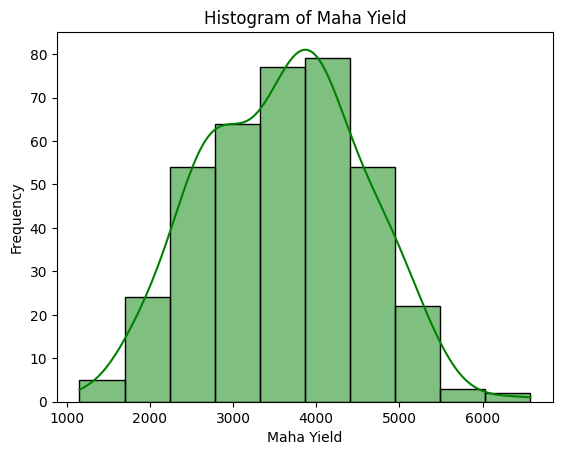

In [80]:
# Histogram of Maha yield
sns.histplot(maha_yield['Yield'], kde=True, bins=10, color='green')
plt.title('Histogram of Maha Yield')
plt.xlabel('Maha Yield')
plt.ylabel('Frequency')
plt.show()



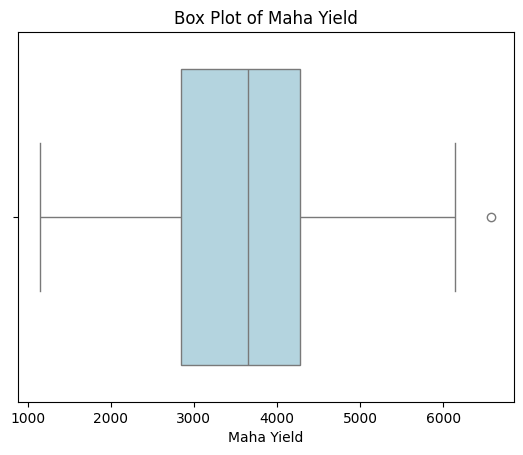

In [81]:
# Box Plot of Maha Yield
sns.boxplot(x=maha_yield['Yield'], color='lightblue')
plt.title('Box Plot of Maha Yield')
plt.xlabel('Maha Yield')
plt.show()

In [82]:
import pandas as pd
import numpy as np

# Calculate the IQR (Interquartile Range)
Q1 = maha_yield['Yield'].quantile(0.25)
Q3 = maha_yield['Yield'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find rows where Yield is an outlier
outliers = maha_yield[(maha_yield['Yield'] < lower_bound) | (maha_yield['Yield'] > upper_bound)]

# Print the outlier rows
display(outliers)


,District,Year,Yield,Cultivation_Season
359,HAMBANTOTA,2013,6575,2012-2013


## Preprocessing Weather Dataset

In [83]:
file_path = '/content/drive/MyDrive/NEW_monthly_weather_data.csv'

# Load the dataset
weather_data = pd.read_csv(file_path)
weather_data.head()


,Year,Month,District,Tmax,SRAD,RH,Rain
0,1984,1,BATTICALOA,27.56,12.71,85.08,331.78
1,1984,1,JAFFNA,27.17,13.10,84.14,192.61
2,1984,1,MANNAR,27.97,14.18,87.13,254.00
3,1984,1,MONARAGALA,27.58,13.96,92.02,279.90
4,1984,1,MULLATIVU,26.89,13.10,84.98,266.93


### Handling Missing Values

In [84]:
# Select only numeric columns
numeric_columns = weather_data.select_dtypes(include=['number'])

# Check for missing values in numeric columns
missing_values_numeric = numeric_columns.isnull().sum()
print("Missing Values:\n", missing_values_numeric, "\n")

# Check for negative values in numeric columns
negative_values_numeric = (numeric_columns < 0).sum()
print("Negative Values:\n", negative_values_numeric)


Missing Values:
 Year     0
Month    0
Tmax     0
SRAD     0
RH       0
Rain     0
dtype: int64 

Negative Values:
 Year     0
Month    0
Tmax     0
SRAD     0
RH       0
Rain     0
dtype: int64


### Determine Relevant Months for Maha Season

The Maha season in Sri Lanka spans from **September to March** in the following year, roughly covering **Standard Meteorological Weeks (SMWs) 36 to 13**, which crosses over two calendar years. This aligns with the North-East Monsoon and represents one of the two main paddy cultivation seasons in Sri Lanka, as defined by the *Department of Census and Statistics in Sri Lanka*.

### Filter Data for the Maha Season

In [85]:
# Define Maha season months
maha_months_full = [8, 9, 10, 11, 12]

maha_season_data = weather_data[
    (
        ((weather_data['Month'].isin([8, 9, 10, 11, 12])) & (weather_data['Year'] == 1984)) |
        ((weather_data['Month'].isin(maha_months_full)) & (weather_data['Year'] > 1984) & (weather_data['Year'] < 2015))
    )
]

# Display the filtered dataset
display(maha_season_data)


,Year,Month,District,Tmax,SRAD,RH,Rain
84,1984,8,BATTICALOA,32.13,19.53,72.28,53.23
85,1984,8,JAFFNA,30.79,21.48,76.33,23.38
86,1984,8,MANNAR,31.07,21.30,78.19,14.91
87,1984,8,MONARAGALA,33.08,19.79,72.44,38.25
88,1984,8,MULLATIVU,31.27,21.48,77.58,30.63
...,...,...,...,...,...,...,...
4459,2014,12,TRINCOMALEE,28.30,11.78,88.11,671.55
4460,2014,12,VAVUNIYA,28.73,11.07,90.79,505.92
4461,2014,12,HAMBANTOTA,28.72,13.51,86.73,707.49
4462,2014,12,AMPARA,28.30,10.78,87.59,866.01


In [86]:
maha_season_data = maha_season_data.copy()

In [87]:
# Assign Cultivation Season based on months
maha_season_data['Cultivation_Season'] = np.where(
    maha_season_data['Month'] >= 8,
    maha_season_data['Year'].astype(str) + '-' + (maha_season_data['Year'] + 1).astype(str),
    (maha_season_data['Year'] - 1).astype(str) + '-' + maha_season_data['Year'].astype(str)
)

cols = list(maha_season_data.columns)
cols.insert(1, cols.pop(cols.index('Cultivation_Season')))

# Apply new column order
maha_season_data = maha_season_data[cols]

# Display modified dataframe
display(maha_season_data.head(20))


,Year,Cultivation_Season,Month,District,Tmax,SRAD,RH,Rain
84,1984,1984-1985,8,BATTICALOA,32.13,19.53,72.28,53.23
85,1984,1984-1985,8,JAFFNA,30.79,21.48,76.33,23.38
86,1984,1984-1985,8,MANNAR,31.07,21.30,78.19,14.91
87,1984,1984-1985,8,MONARAGALA,33.08,19.79,72.44,38.25
88,1984,1984-1985,8,MULLATIVU,31.27,21.48,77.58,30.63
89,1984,1984-1985,8,POLONNARUWA,33.45,19.53,77.00,54.60
90,1984,1984-1985,8,PUTTALAM,30.67,21.30,83.33,15.56
91,1984,1984-1985,8,TRINCOMALEE,32.42,19.40,79.22,73.03
92,1984,1984-1985,8,VAVUNIYA,33.33,21.48,78.44,31.83
93,1984,1984-1985,8,HAMBANTOTA,29.04,19.79,84.41,45.28


## Merge Weather and Yield Data

In [88]:
maha_season_data = maha_season_data.drop(columns=['Year'])

# Merge the weather data with the yield data
merged_data = maha_season_data.merge(
    maha_yield,
    on=['District', 'Cultivation_Season'],
    how='inner'
)

display(merged_data.head(20))


,Cultivation_Season,Month,District,Tmax,SRAD,RH,Rain,Year,Yield
0,1984-1985,8,BATTICALOA,32.13,19.53,72.28,53.23,1985,3163
1,1984-1985,8,JAFFNA,30.79,21.48,76.33,23.38,1985,1687
2,1984-1985,8,MANNAR,31.07,21.30,78.19,14.91,1985,3781
3,1984-1985,8,MONARAGALA,33.08,19.79,72.44,38.25,1985,2988
4,1984-1985,8,MULLATIVU,31.27,21.48,77.58,30.63,1985,2579
5,1984-1985,8,POLONNARUWA,33.45,19.53,77.00,54.60,1985,4874
6,1984-1985,8,PUTTALAM,30.67,21.30,83.33,15.56,1985,2643
7,1984-1985,8,TRINCOMALEE,32.42,19.40,79.22,73.03,1985,3379
8,1984-1985,8,VAVUNIYA,33.33,21.48,78.44,31.83,1985,2946
9,1984-1985,8,HAMBANTOTA,29.04,19.79,84.41,45.28,1985,4328


In [89]:
# Weather variables and month names in seasonal order
weather_variables = ['Tmax', 'SRAD', 'RH', 'Rain']
month_names = ['Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_name_map = dict(zip([8, 9, 10, 11, 12], month_names))


In [90]:
# Create a copy of the data
pivot_data = merged_data.copy()

# Extract the yield year from the Cultivation_Season
pivot_data['Year'] = pivot_data['Cultivation_Season'].apply(lambda x: int(x.split('-')[1]))

# Pivot to wide format with month-specific columns
pivot_data = pivot_data.pivot_table(
    index=['Cultivation_Season', 'District', 'Year', 'Yield'],
    columns='Month',
    values=weather_variables,
    aggfunc='first'
)

# Flatten MultiIndex columns
pivot_data.columns = [f"{month_name_map[month]}_{var}" for var, month in pivot_data.columns]

# Reset index to keep 'Year' as a regular column
pivot_data = pivot_data.reset_index()

# Ensure the correct seasonal column order
ordered_columns = (
    ['Cultivation_Season', 'District', 'Year', 'Yield'] +
    [f"{month}_{var}" for month in month_names for var in weather_variables]
)

# Reorder the DataFrame columns
pivot_data = pivot_data[ordered_columns]

# Display the restructured DataFrame
display(pivot_data.head(20))


,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_SRAD,...,Oct_RH,Oct_Rain,Nov_Tmax,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_SRAD,Dec_RH,Dec_Rain
0,1984-1985,AMPARA,1985,3827,32.13,19.53,72.28,53.23,33.00,19.81,...,76.50,151.14,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80
1,1984-1985,ANURADHAPURA,1985,3972,34.34,21.48,79.94,32.92,35.49,17.28,...,85.28,115.19,30.03,17.14,88.92,278.85,29.50,15.33,87.58,85.09
2,1984-1985,BATTICALOA,1985,3163,32.13,19.53,72.28,53.23,33.00,19.81,...,76.50,151.14,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80
3,1984-1985,HAMBANTOTA,1985,4328,29.04,19.79,84.41,45.28,29.40,19.80,...,83.41,209.60,28.33,17.65,81.97,327.30,28.24,16.66,82.28,49.10
4,1984-1985,JAFFNA,1985,1687,30.79,21.48,76.33,23.38,30.54,19.14,...,79.45,101.59,28.77,15.47,81.68,226.04,27.82,13.99,79.70,94.21
5,1984-1985,MANNAR,1985,3781,31.07,21.30,78.19,14.91,31.28,20.31,...,81.69,91.90,29.19,16.57,84.00,256.05,28.43,15.75,82.49,87.11
6,1984-1985,MONARAGALA,1985,2988,33.08,19.79,72.44,38.25,34.37,19.80,...,80.14,199.65,28.56,17.65,88.76,237.55,29.15,16.66,88.40,52.62
7,1984-1985,MULLATIVU,1985,2579,31.27,21.48,77.58,30.63,31.51,19.14,...,80.73,103.23,28.90,15.47,82.82,262.20,27.69,13.99,80.46,104.56
8,1984-1985,POLONNARUWA,1985,4874,33.45,19.53,77.00,54.60,35.05,19.81,...,83.97,113.58,30.11,16.61,86.68,303.79,29.84,15.23,85.72,95.29
9,1984-1985,PUTTALAM,1985,2643,30.67,21.30,83.33,15.56,31.54,20.31,...,82.81,146.78,29.74,16.57,85.44,286.65,29.67,15.75,84.33,53.05


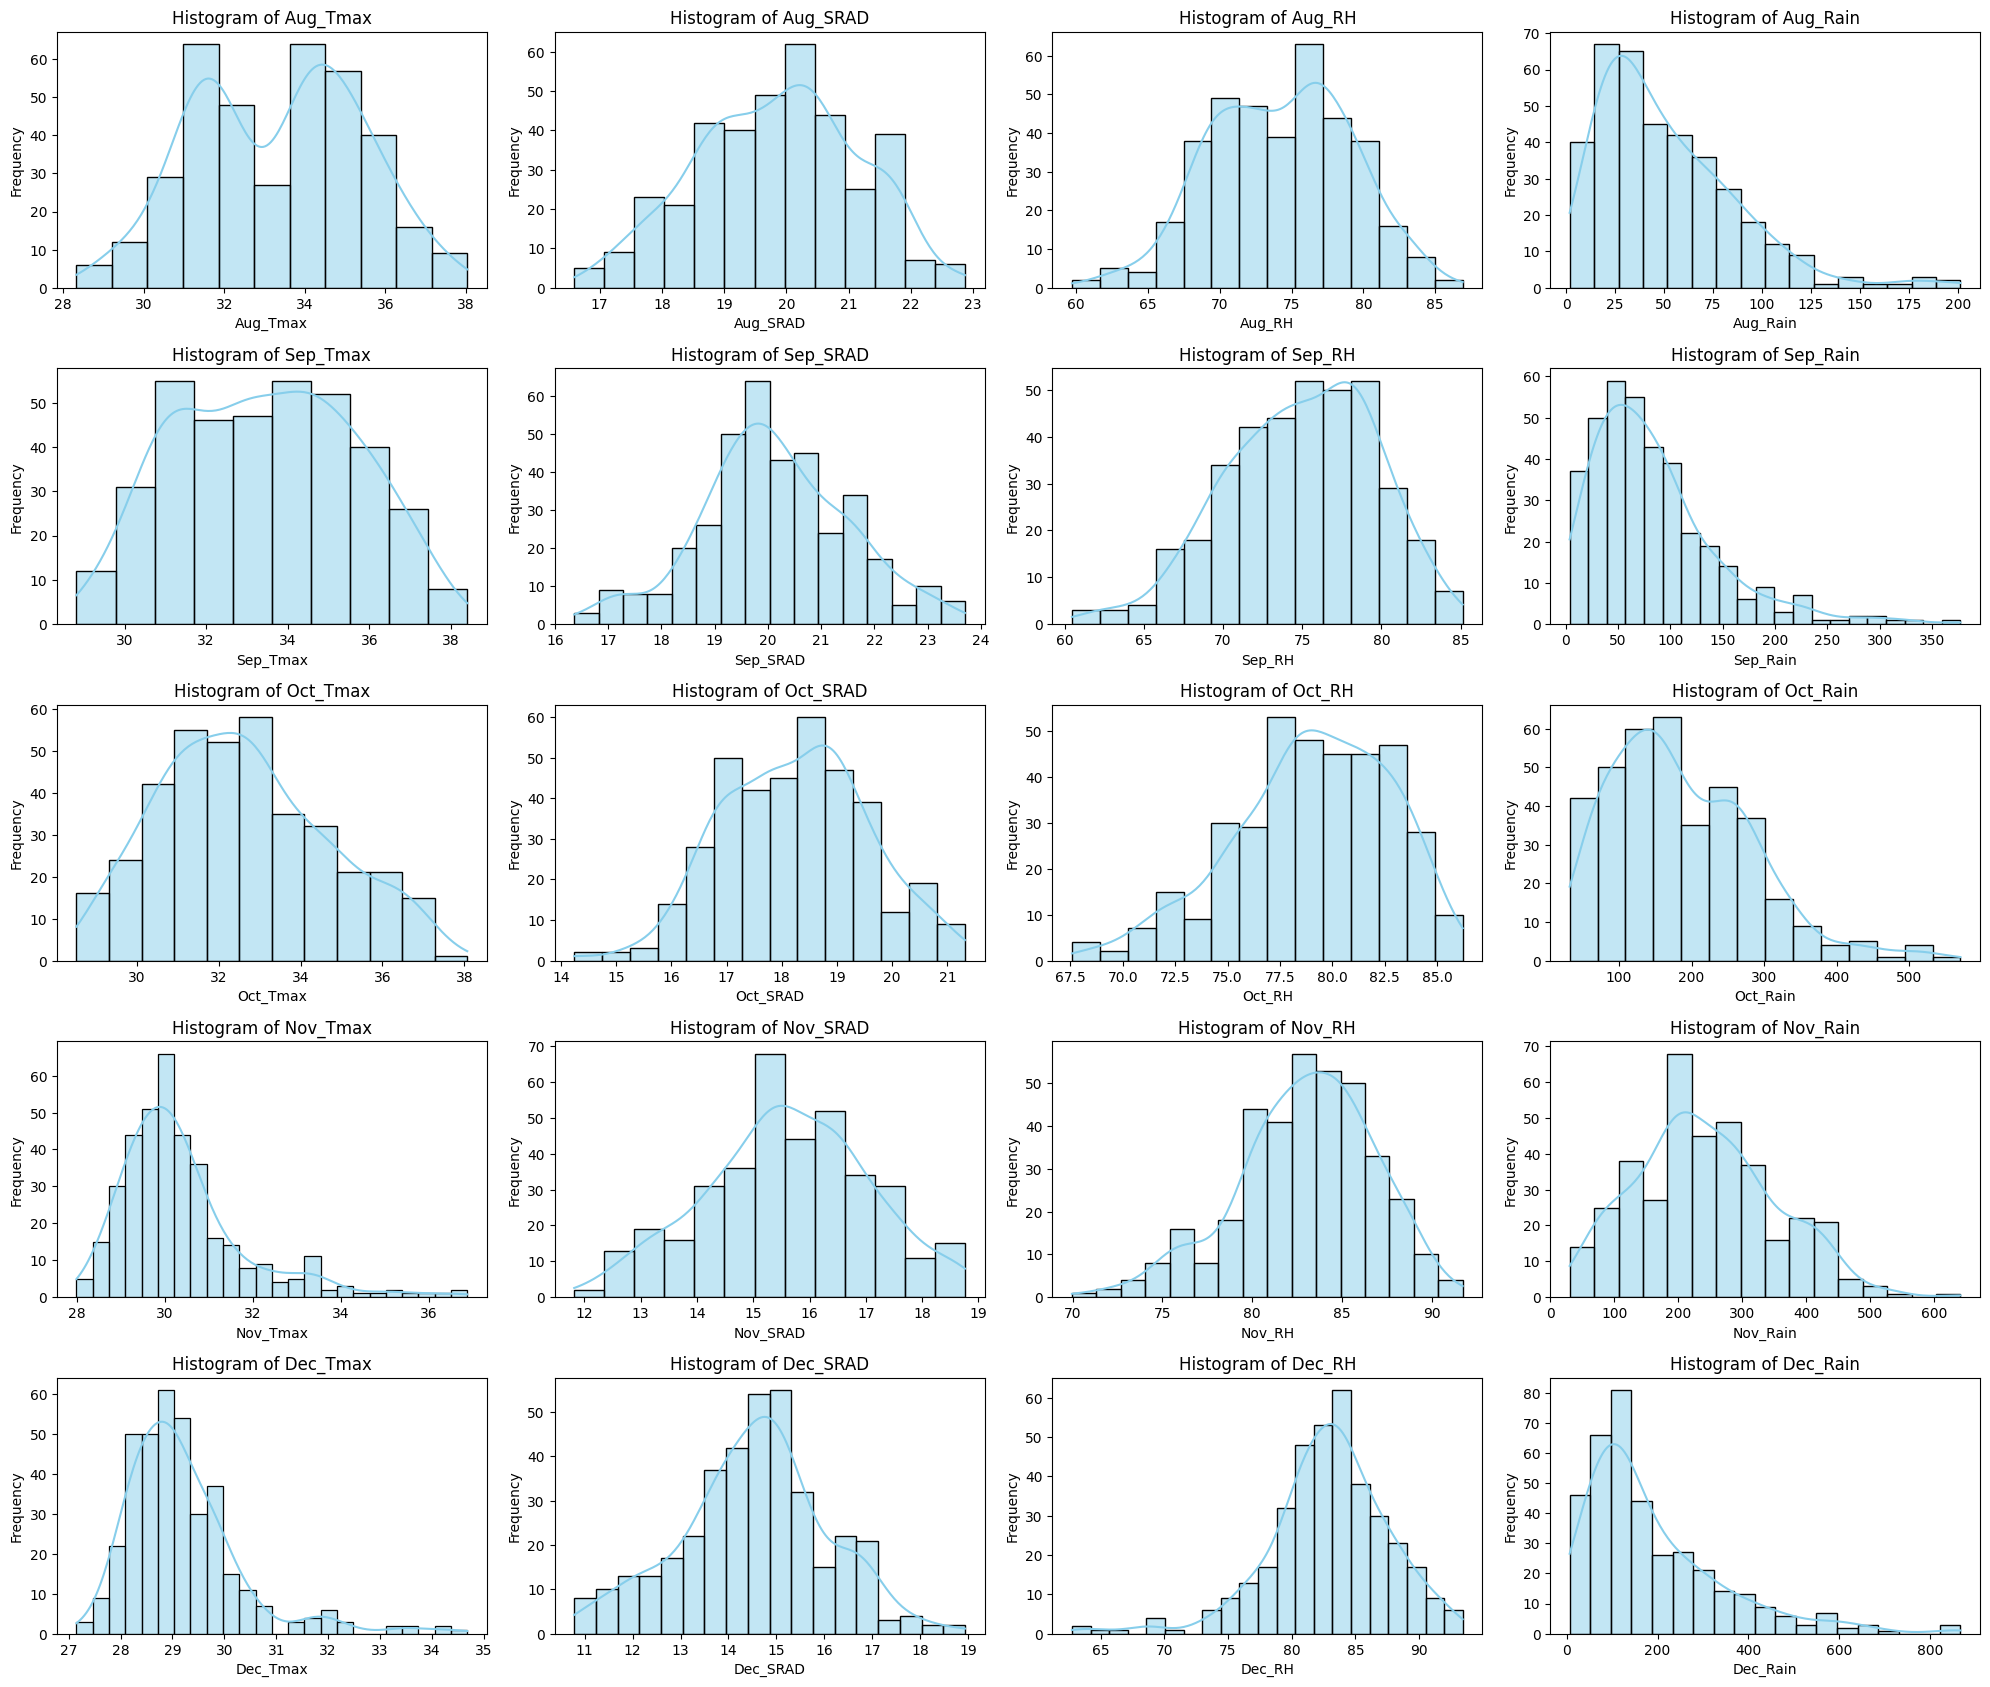

In [91]:
# Select all weather variables excluding non-numeric columns
weather_columns = [col for col in pivot_data.columns if col not in ['Cultivation_Season', 'District', 'Year', 'Yield']]

# Generate histograms for each weather variable
plt.figure(figsize=(20, 30))

for i, variable in enumerate(weather_columns, start=1):
    plt.subplot(9, 4, i)
    sns.histplot(pivot_data[variable], kde=True, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


### Handling outliers

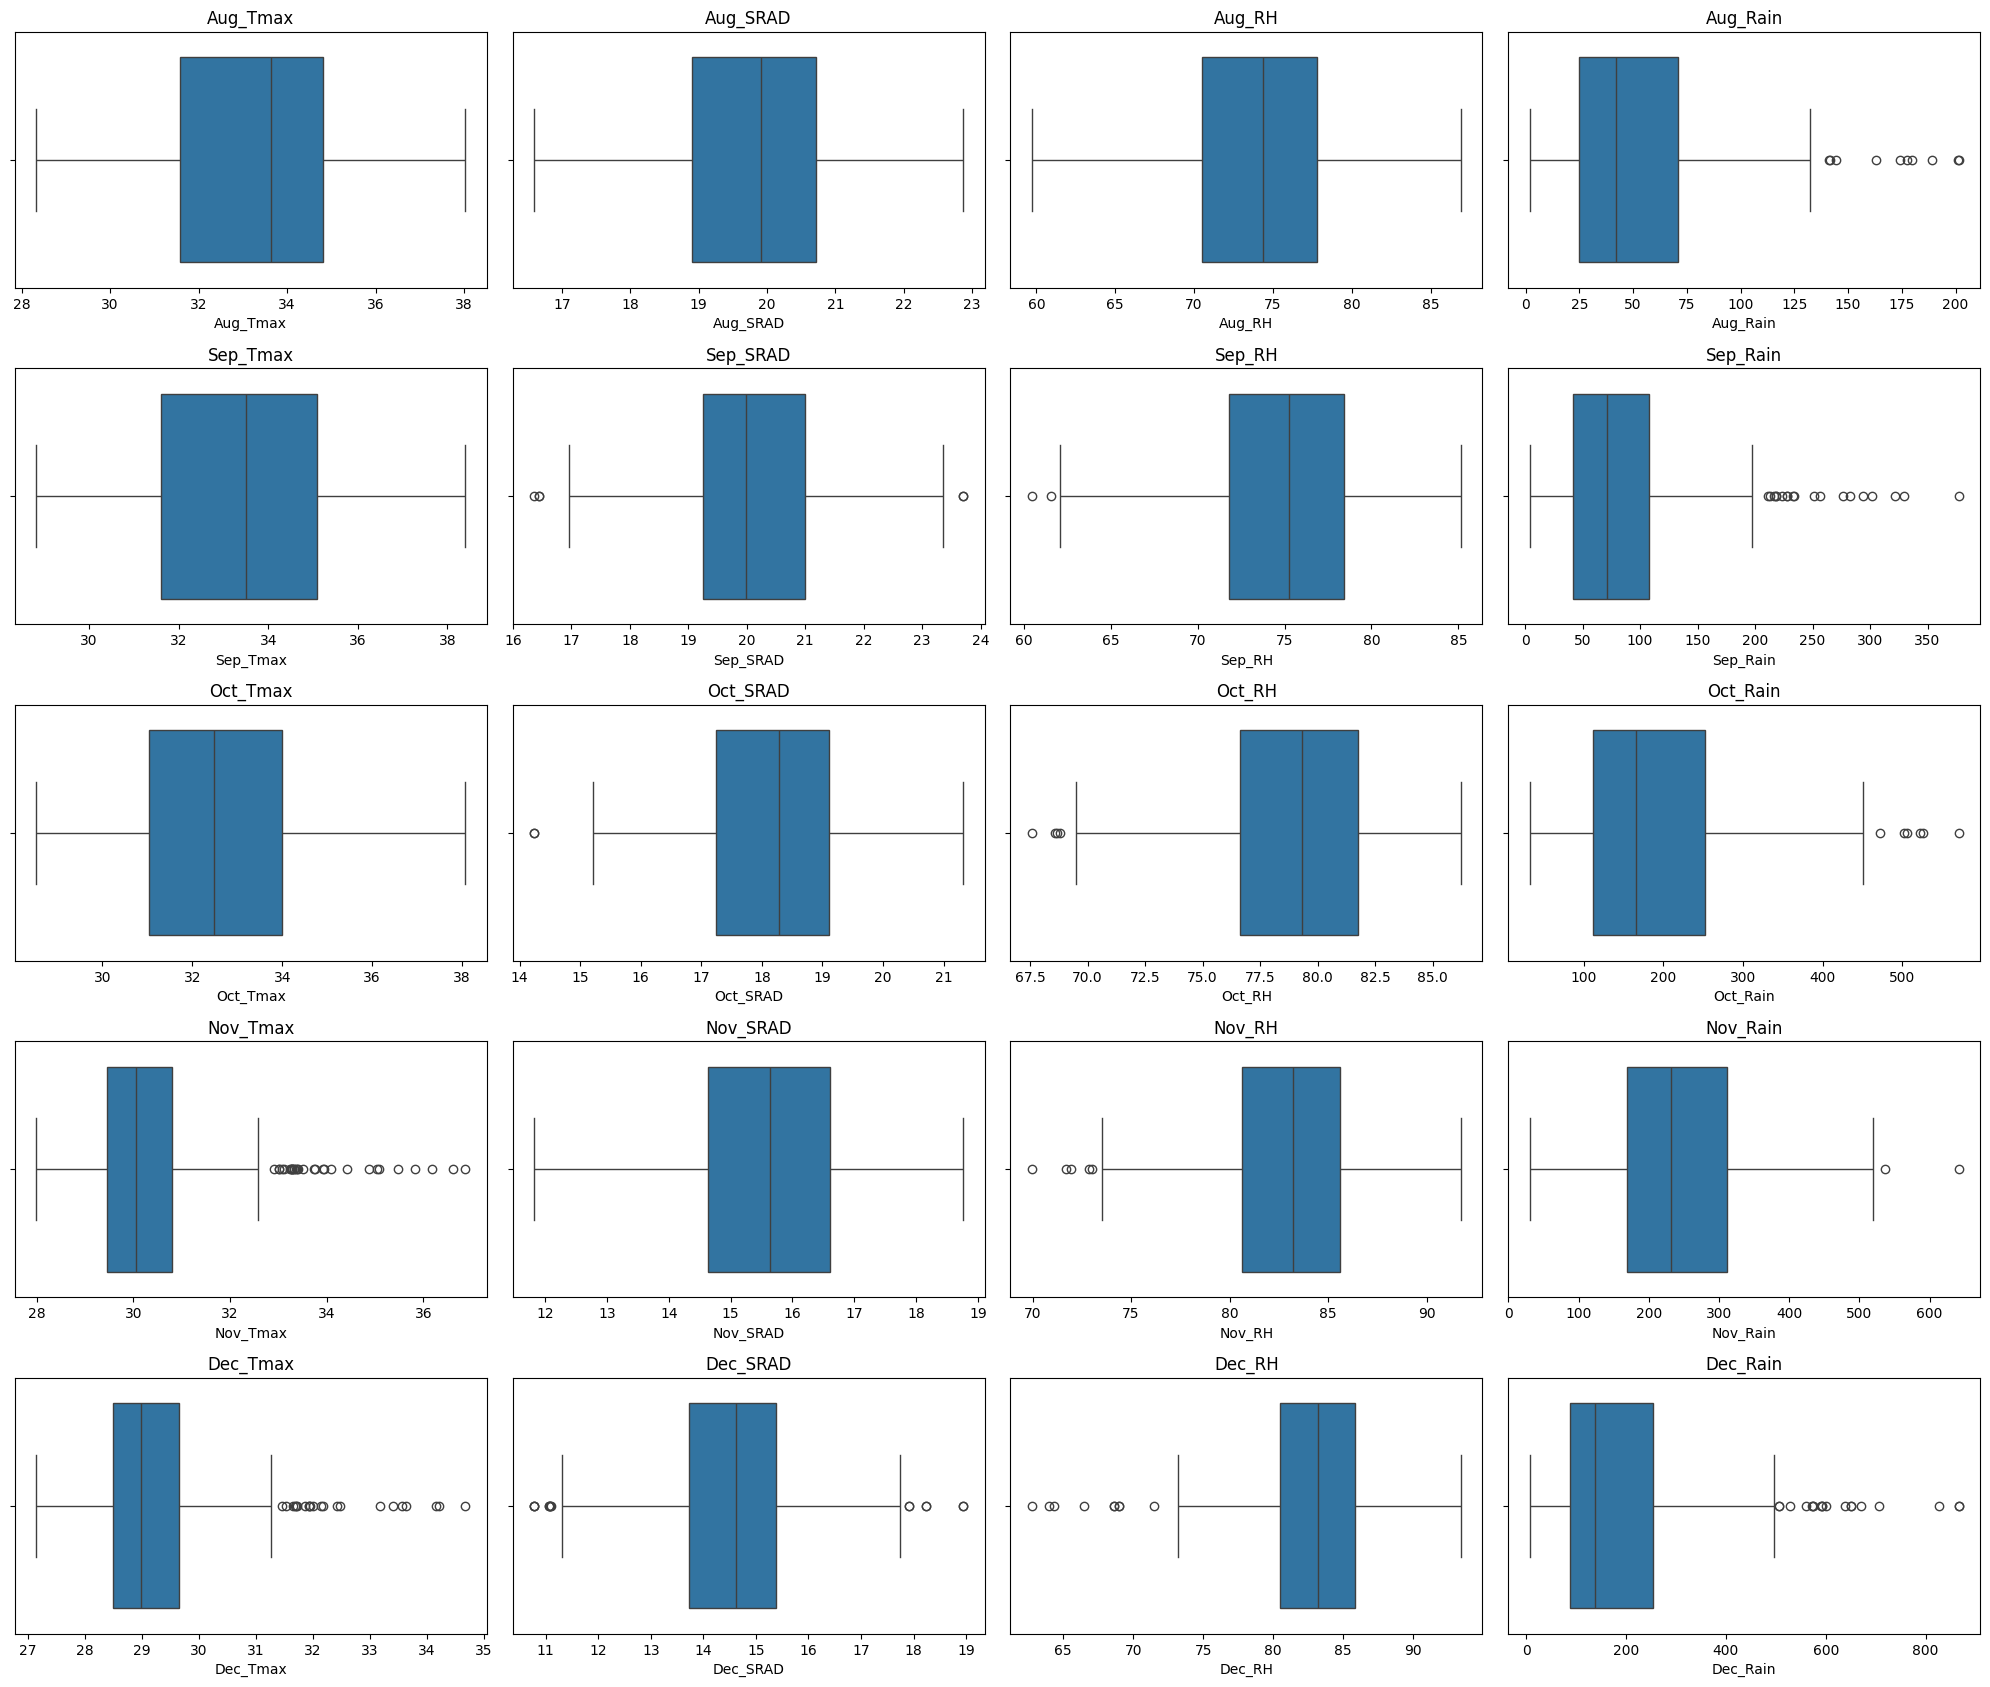

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select all weather variables excluding non-numeric columns
weather_columns = [col for col in pivot_data.columns if col not in ['Cultivation_Season', 'District', 'Year', 'Yield']]

# Generate horizontal box plots for each weather variable
plt.figure(figsize=(20, 30))

for i, variable in enumerate(weather_columns, start=1):
    plt.subplot(9, 4, i)
    sns.boxplot(x=pivot_data[variable])
    plt.title(f'{variable}')
    plt.xlabel(variable)

plt.tight_layout()
plt.show()


In [93]:
import numpy as np

# Function for handling outliers (capping) with in-place updates
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Update the DataFrame column with capped values directly
    df[column] = np.clip(df[column], lower_bound, upper_bound)


In [94]:
# Select all weather variables excluding non-numeric columns
weather_columns = [col for col in pivot_data.columns if col not in ['Cultivation_Season', 'District', 'Year', 'Yield']]

# Apply outlier capping to all weather variables
for variable in weather_columns:
    cap_outliers(pivot_data, variable)


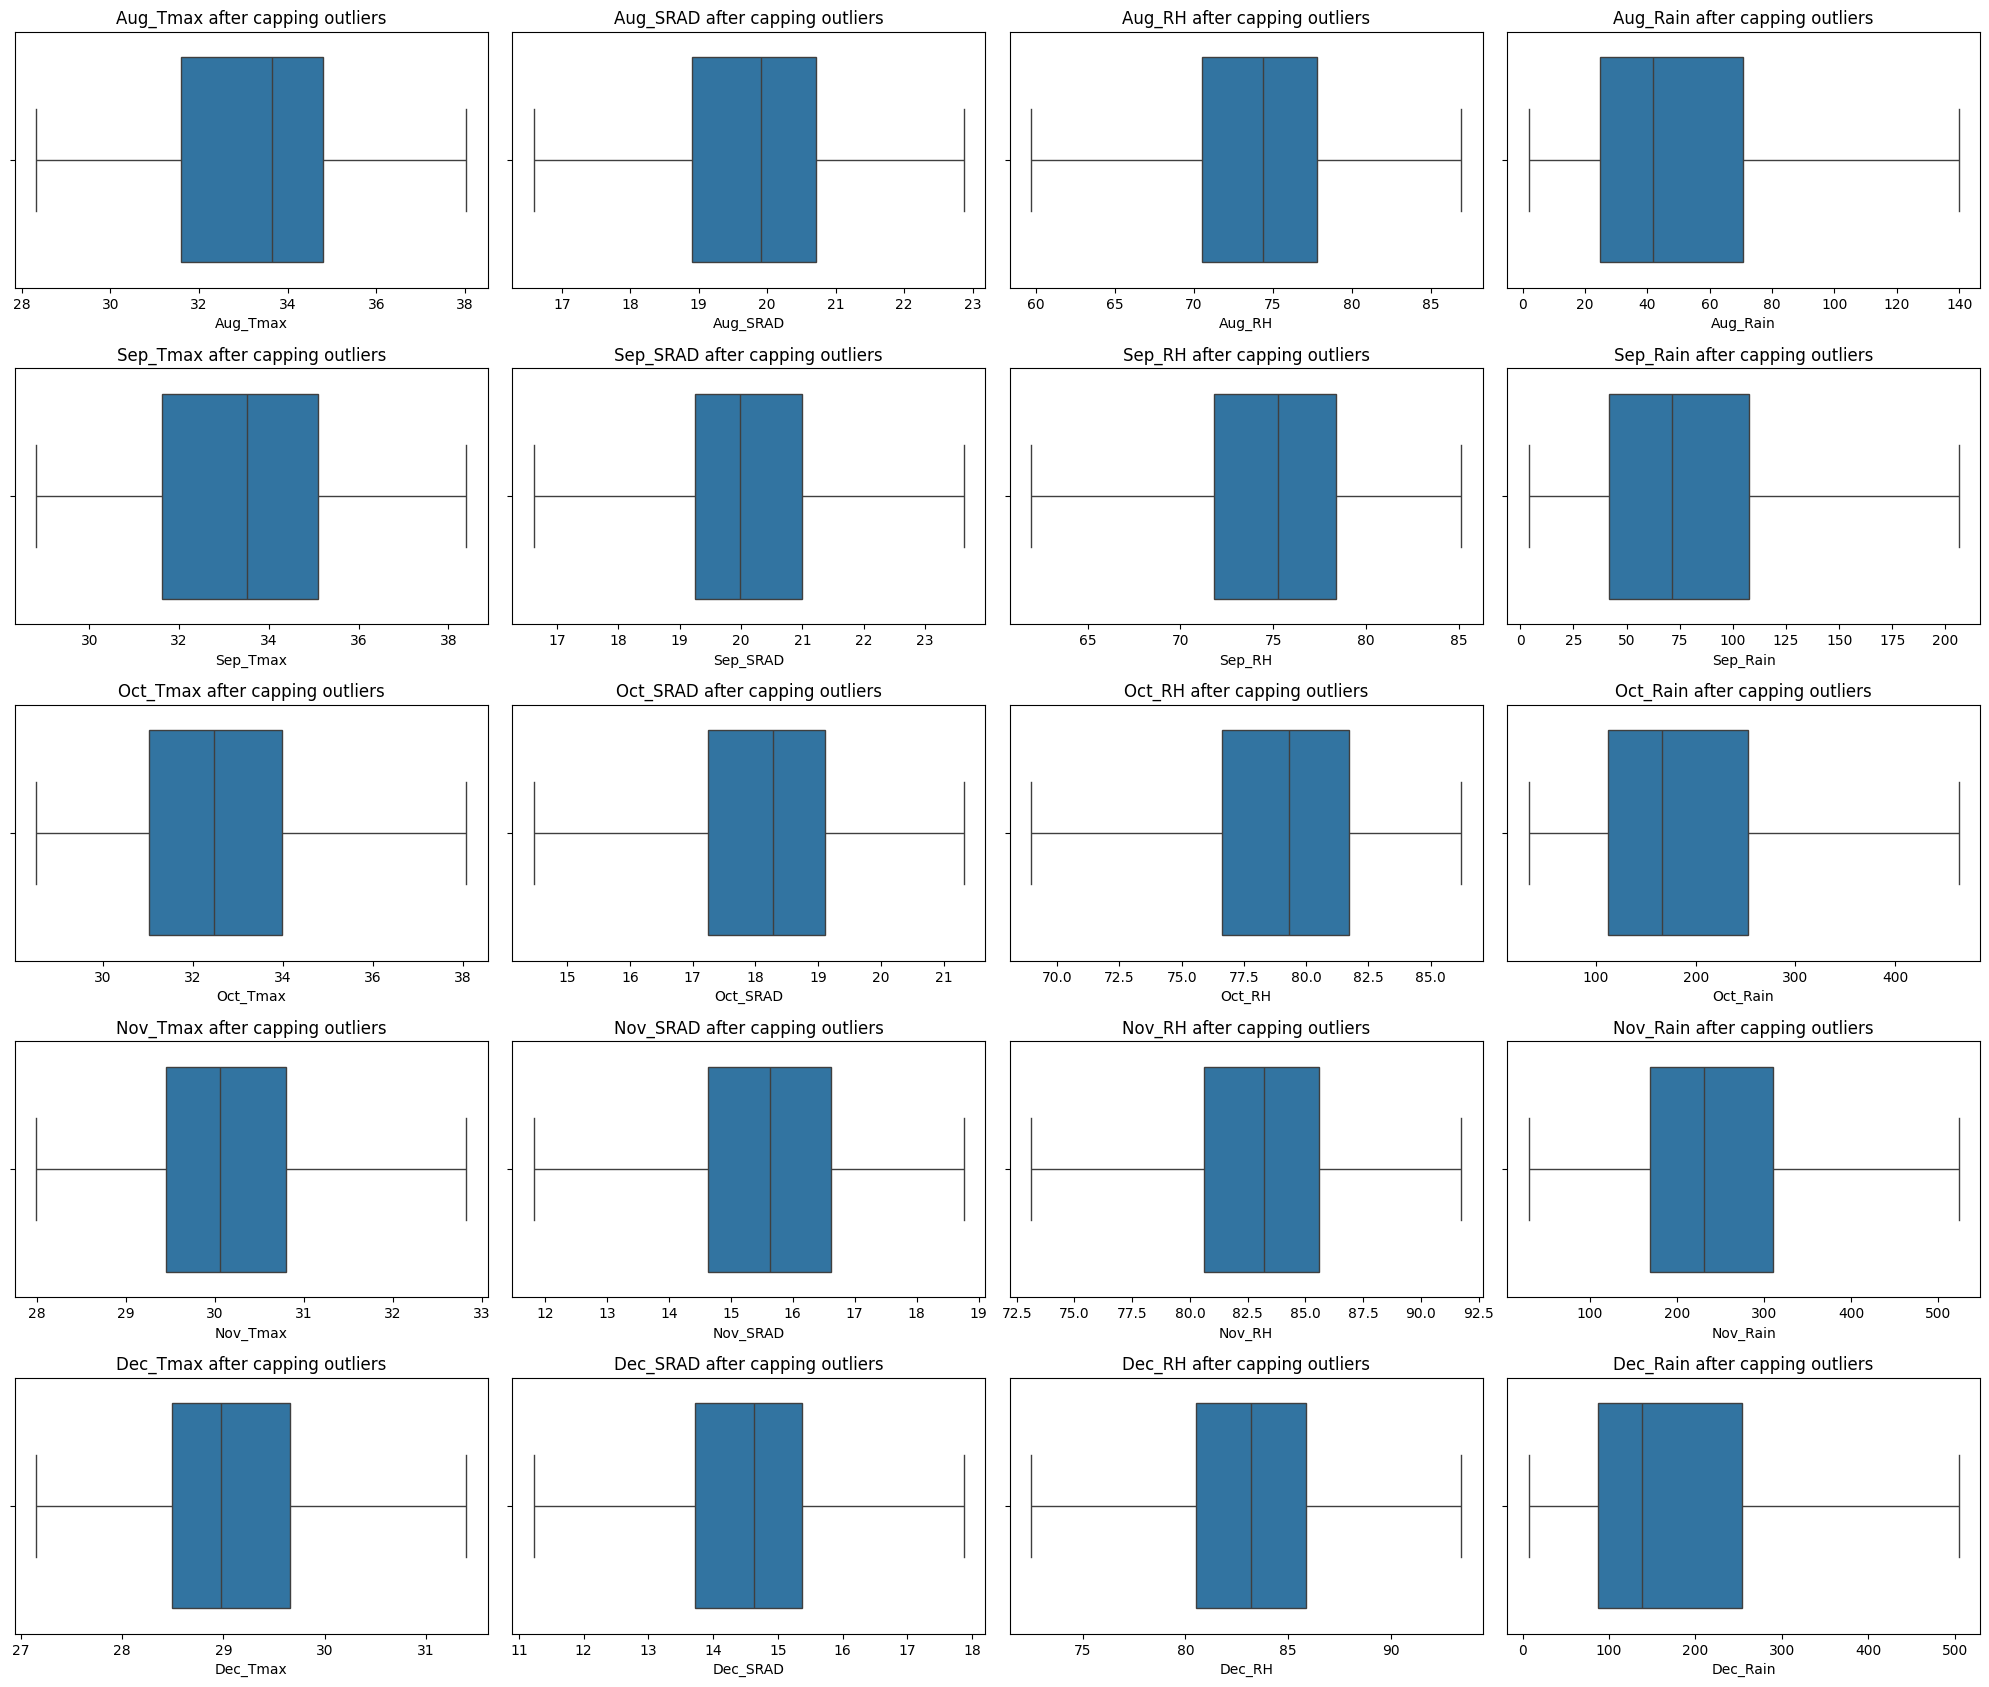

In [95]:
# Generate horizontal box plots for each weather variable after capping outliers
plt.figure(figsize=(20, 30))

for i, variable in enumerate(weather_columns, start=1):
    plt.subplot(9, 4, i)
    sns.boxplot(x=pivot_data[variable])
    plt.title(f'{variable} after capping outliers')
    plt.xlabel(variable)

plt.tight_layout()
plt.show()

### Correlation of Weather Variables with Final Yield

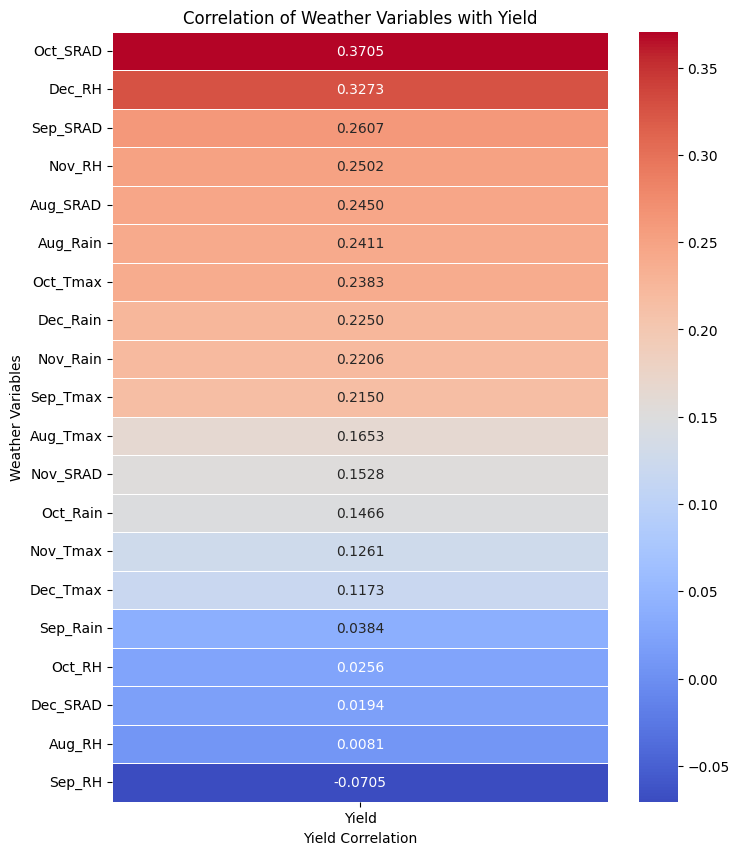

In [96]:
# Calculate the correlation of all weather variables with Yield
correlation_df = pivot_data[weather_columns + ['Yield']].corr()['Yield'].drop('Yield').sort_values(ascending=False)

# Convert to DataFrame for heatmap
correlation_matrix = correlation_df.to_frame()

# Plot the heatmap
plt.figure(figsize=(8, len(correlation_df) * 0.5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5, cbar=True)

# Titles and labels
plt.title("Correlation of Weather Variables with Yield")
plt.xlabel("Yield Correlation")
plt.ylabel("Weather Variables")

# Show the plot
plt.show()

In [97]:
# Select all weather variables excluding non-numeric columns
weather_cols = [col for col in pivot_data.columns if col not in ['Cultivation_Season', 'District', 'Year', 'Yield']]


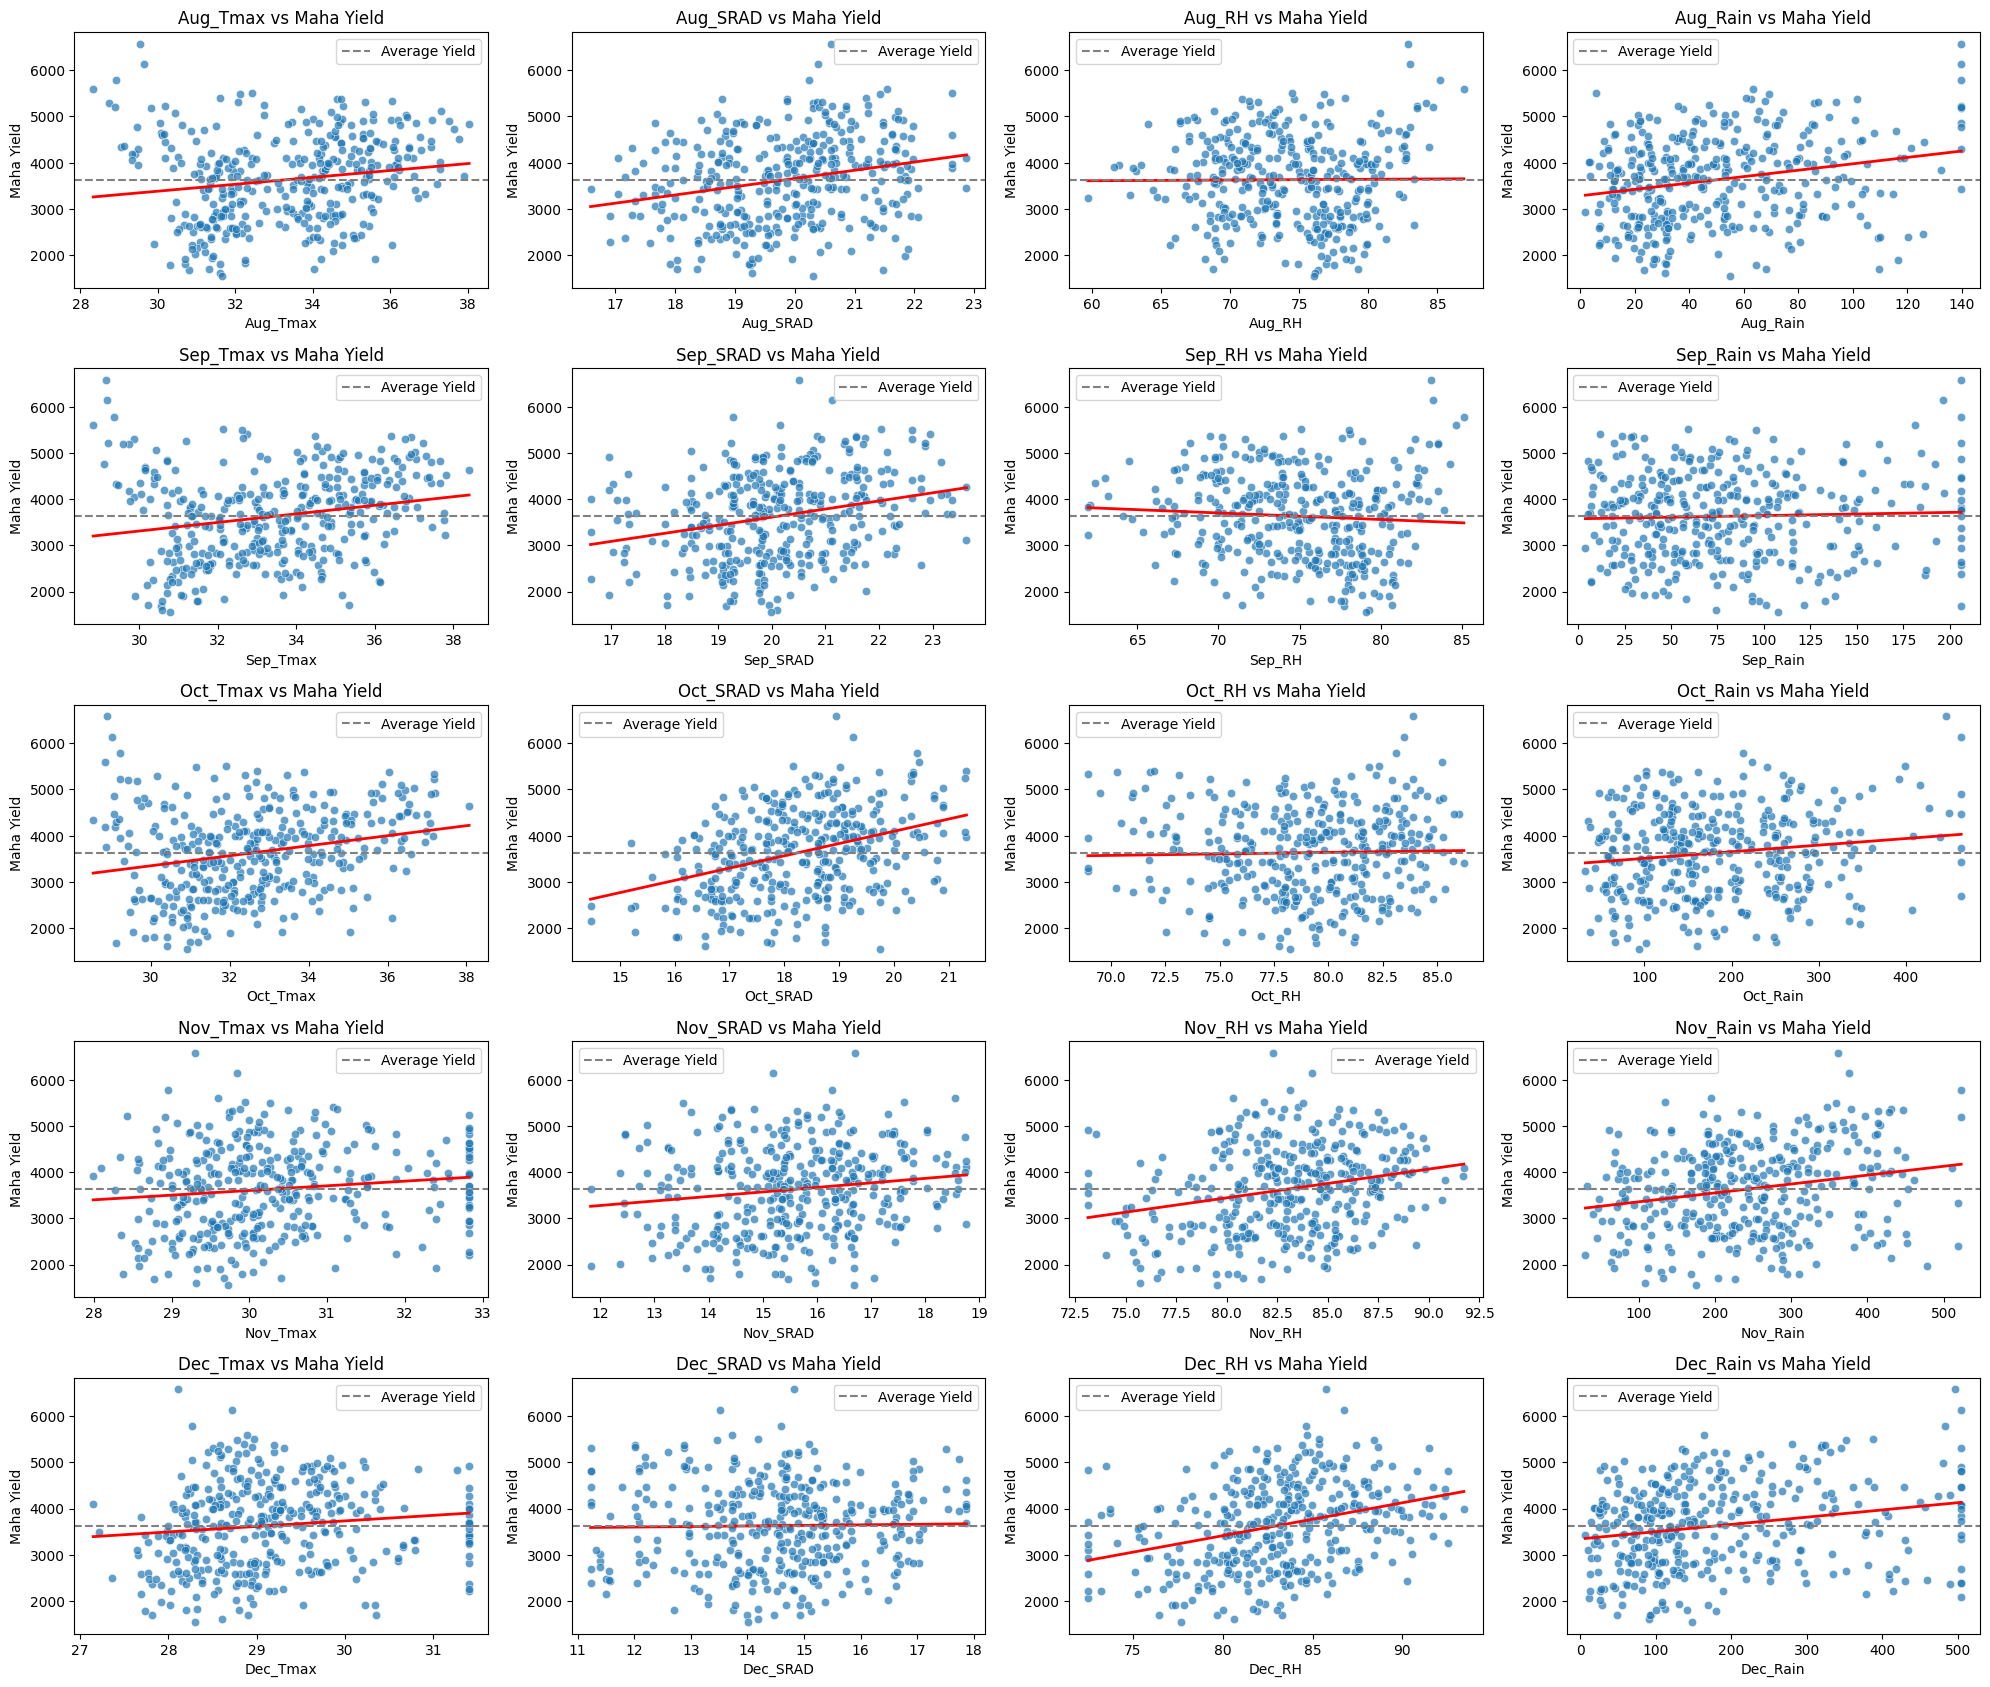

In [98]:
plt.figure(figsize=(20, 30))

for i, variable in enumerate(weather_cols, start=1):
    plt.subplot(9, 4, i)
    sns.scatterplot(x=pivot_data[variable], y=pivot_data['Yield'], alpha=0.7)
    sns.regplot(x=pivot_data[variable], y=pivot_data['Yield'], scatter=False, ci=None, color='red', line_kws={"linewidth": 2})
    plt.title(f'{variable} vs Maha Yield')
    plt.xlabel(variable)
    plt.ylabel('Maha Yield')
    plt.axhline(y=pivot_data['Yield'].mean(), color='gray', linestyle='--', label='Average Yield')
    plt.legend()

plt.tight_layout()
plt.show()

In [99]:
# Ensure the final dataframe includes the selected features + Yield
final_df = pivot_data[weather_cols + ['Yield']].copy()

# Display the final DataFrame
display(final_df.head())


,Aug_Tmax,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_SRAD,...,Oct_Rain,Nov_Tmax,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_SRAD,Dec_RH,Dec_Rain,Yield
0,32.13,19.53,72.28,53.23,33.00,19.81,71.84,206.12875,31.03,18.66,...,151.14,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80,3827
1,34.34,21.48,79.94,32.92,35.49,17.28,78.64,206.12875,30.75,18.02,...,115.19,30.03,17.14,88.92,278.85,29.50,15.33,87.58,85.09,3972
2,32.13,19.53,72.28,53.23,33.00,19.81,71.84,206.12875,31.03,18.66,...,151.14,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80,3163
3,29.04,19.79,84.41,45.28,29.40,19.80,80.97,175.33000,28.53,18.61,...,209.60,28.33,17.65,81.97,327.30,28.24,16.66,82.28,49.10,4328
4,30.79,21.48,76.33,23.38,30.54,19.14,77.73,206.12875,29.12,17.76,...,101.59,28.77,15.47,81.68,226.04,27.82,13.99,79.70,94.21,1687


In [100]:
from scipy.stats import skew

# Calculate skewness
skewness = skew(final_df['Yield'])

# Print result with interpretation
print(f"Skewness: {skewness:.4f}")

# Interpretation
if -0.5 <= skewness <= 0.5:
    print("The data is fairly symmetric (close to normal).")
elif -1 <= skewness < -0.5 or 0.5 < skewness <= 1:
    print("The data is moderately skewed.")
else:
    print("The data is highly skewed.")


Skewness: 0.0556
The data is fairly symmetric (close to normal).


In [101]:
# Determine min and max for equal-width binning
min_yield = final_df['Yield'].min()
max_yield = final_df['Yield'].max()

# Create equal-width bins
bins = np.linspace(min_yield, max_yield, num=4)

# Assign labels based on bin ranges
final_df['Yield_Class'] = pd.cut(final_df['Yield'], bins=bins, labels=['Low', 'Medium', 'High'], include_lowest=True)


In [102]:
# Print bin edges
print("\nYield Class Ranges:")
for i in range(len(bins) - 1):
    print(f"Class {i+1} ({['Low', 'Medium', 'High'][i]}): {bins[i]:.2f} to {bins[i+1]:.2f}")


Yield Class Ranges:
Class 1 (Low): 1547.00 to 3223.00
Class 2 (Medium): 3223.00 to 4899.00
Class 3 (High): 4899.00 to 6575.00


In [103]:
display(final_df.head())

,Aug_Tmax,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_SRAD,...,Nov_Tmax,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_SRAD,Dec_RH,Dec_Rain,Yield,Yield_Class
0,32.13,19.53,72.28,53.23,33.00,19.81,71.84,206.12875,31.03,18.66,...,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80,3827,Medium
1,34.34,21.48,79.94,32.92,35.49,17.28,78.64,206.12875,30.75,18.02,...,30.03,17.14,88.92,278.85,29.50,15.33,87.58,85.09,3972,Medium
2,32.13,19.53,72.28,53.23,33.00,19.81,71.84,206.12875,31.03,18.66,...,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80,3163,Low
3,29.04,19.79,84.41,45.28,29.40,19.80,80.97,175.33000,28.53,18.61,...,28.33,17.65,81.97,327.30,28.24,16.66,82.28,49.10,4328,Medium
4,30.79,21.48,76.33,23.38,30.54,19.14,77.73,206.12875,29.12,17.76,...,28.77,15.47,81.68,226.04,27.82,13.99,79.70,94.21,1687,Low


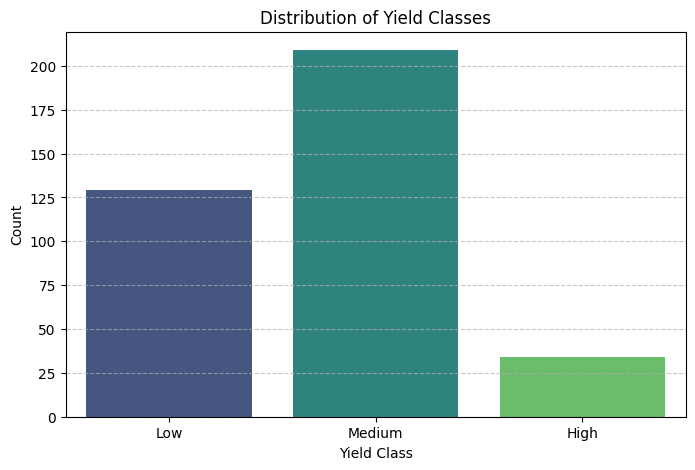

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot for class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Yield_Class', hue='Yield_Class', data=final_df, palette='viridis')

# Add labels
plt.title('Distribution of Yield Classes')
plt.xlabel('Yield Class')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()


In [105]:
# Drop the 'Yield' column from the final DataFrame
final_df = final_df.drop(columns=['Yield'])

# Display the updated DataFrame
display(final_df.head())


,Aug_Tmax,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_SRAD,...,Oct_Rain,Nov_Tmax,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_SRAD,Dec_RH,Dec_Rain,Yield_Class
0,32.13,19.53,72.28,53.23,33.00,19.81,71.84,206.12875,31.03,18.66,...,151.14,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80,Medium
1,34.34,21.48,79.94,32.92,35.49,17.28,78.64,206.12875,30.75,18.02,...,115.19,30.03,17.14,88.92,278.85,29.50,15.33,87.58,85.09,Medium
2,32.13,19.53,72.28,53.23,33.00,19.81,71.84,206.12875,31.03,18.66,...,151.14,28.71,16.61,83.00,294.75,28.19,15.23,82.81,76.80,Low
3,29.04,19.79,84.41,45.28,29.40,19.80,80.97,175.33000,28.53,18.61,...,209.60,28.33,17.65,81.97,327.30,28.24,16.66,82.28,49.10,Medium
4,30.79,21.48,76.33,23.38,30.54,19.14,77.73,206.12875,29.12,17.76,...,101.59,28.77,15.47,81.68,226.04,27.82,13.99,79.70,94.21,Low


In [106]:
final_df.to_csv('/content/FINAL_yield_pred_data.csv', index=False)

## Split Data into Train-Test Sets

In [107]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [108]:
# Load dataset
df = pd.read_csv('/content/FINAL_yield_pred_data.csv')

# Perform 80-20 train-test split
X = df.drop(columns=["Yield_Class"])  # Features
y = df["Yield_Class"]  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Print dataset sizes
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 297
Testing samples: 75


In [109]:
display(X_train.head())

,Aug_Tmax,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_SRAD,Oct_RH,Oct_Rain,Nov_Tmax,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_SRAD,Dec_RH,Dec_Rain
206,34.44,21.63,67.95,12.31,35.22,20.33,70.13,91.50,32.98,19.05,76.24,89.84,31.34,16.41,79.84,211.35,28.59,15.15,81.81,199.18
259,32.30,21.85,75.10,46.96,31.81,19.76,77.65,33.02,31.80,17.01,79.13,197.25,29.38,11.82,84.63,453.06,28.00,15.38,82.41,118.70
42,36.88,17.67,68.63,86.72,36.48,19.22,70.61,102.35,31.62,17.59,84.46,287.89,29.12,17.31,86.90,192.95,29.33,17.04,88.56,87.37
157,36.78,20.05,70.65,17.56,36.54,19.54,74.12,65.42,37.09,16.55,78.19,179.19,30.48,14.75,88.92,221.79,30.00,14.56,88.65,188.68
52,31.31,18.04,79.22,109.45,30.22,18.04,80.71,121.40,30.99,18.74,75.31,66.19,29.67,14.03,76.55,131.35,30.35,14.93,76.47,48.34


## Handle Class Imbalance

In [110]:
# Count samples in each class for training and testing sets
train_class_counts = y_train.value_counts()
test_class_counts = y_test.value_counts()

# Print the class distribution
print("Training Set Class Distribution:\n", train_class_counts)
print("\nTesting Set Class Distribution:\n", test_class_counts)

Training Set Class Distribution:
 Yield_Class
Medium    167
Low       103
High       27
Name: count, dtype: int64

Testing Set Class Distribution:
 Yield_Class
Medium    42
Low       26
High       7
Name: count, dtype: int64


In [111]:
# Convert counts to percentages
train_class_percentages = (train_class_counts / len(y_train)) * 100
test_class_percentages = (test_class_counts / len(y_test)) * 100

# Print the class distribution percentages
print("\nTraining Set Class Distribution Percentages:\n", train_class_percentages)


Training Set Class Distribution Percentages:
 Yield_Class
Medium    56.228956
Low       34.680135
High       9.090909
Name: count, dtype: float64


In [112]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Balanced Training Set Class Distribution:\n", y_train_smote.value_counts())

Balanced Training Set Class Distribution:
 Yield_Class
Low       167
Medium    167
High      167
Name: count, dtype: int64


## Feature Selection

In [113]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train_smote, y_train_smote)



RandomForestClassifier(random_state=42)

In [114]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Predict on training and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Compute accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Print results
    print(f"\n{type(model).__name__} Training Accuracy: {train_accuracy:.4f}")
    print("\nClassification Report (Training Data):")
    print(classification_report(y_train, y_train_pred))

    print(f"\n{type(model).__name__} Test Accuracy: {test_accuracy:.4f}")
    print("\nClassification Report (Test Data):")
    print(classification_report(y_test, y_test_pred))


In [115]:
# Evaluate the model
evaluate_model(rf_model, X_train_smote, X_test, y_train_smote, y_test)



RandomForestClassifier Training Accuracy: 0.9641

Classification Report (Training Data):
              precision    recall  f1-score   support

        High       0.98      1.00      0.99       167
         Low       0.96      0.94      0.95       167
      Medium       0.95      0.95      0.95       167

    accuracy                           0.96       501
   macro avg       0.96      0.96      0.96       501
weighted avg       0.96      0.96      0.96       501


RandomForestClassifier Test Accuracy: 0.6267

Classification Report (Test Data):
              precision    recall  f1-score   support

        High       0.40      0.29      0.33         7
         Low       0.65      0.50      0.57        26
      Medium       0.64      0.76      0.70        42

    accuracy                           0.63        75
   macro avg       0.56      0.52      0.53        75
weighted avg       0.62      0.63      0.62        75



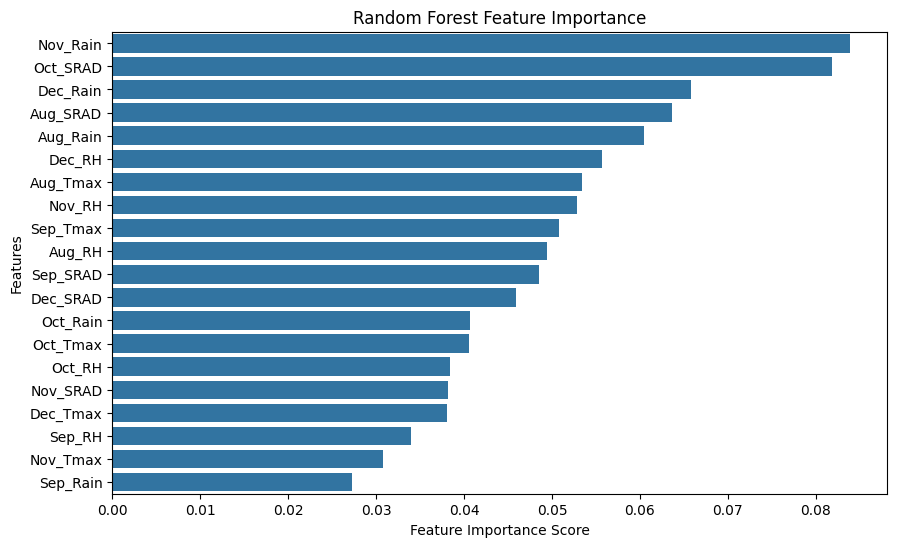

In [116]:
# Get feature importance scores
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Sort and plot
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.sort_values(ascending=False), y=feature_importance.sort_values(ascending=False).index)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()

In [117]:
import pandas as pd

def iterative_feature_selection(model, X_train, X_test, y_train, y_test, feature_names, max_rounds=5):
    X_train_selected = pd.DataFrame(X_train, columns=feature_names)
    X_test_selected = pd.DataFrame(X_test, columns=feature_names)

    removed_features_all = []

    for round_num in range(1, max_rounds + 1):
        print(f"\n --- Starting Round {round_num} of Feature Selection ---")

        # Train model & get feature importances
        model.fit(X_train_selected, y_train)
        feature_importance = pd.Series(model.feature_importances_, index=X_train_selected.columns).sort_values(ascending=True)

        # Store baseline accuracy before removing features
        baseline_acc = accuracy_score(y_test, model.predict(X_test_selected))
        print(f"Baseline Accuracy for Round {round_num}: {baseline_acc:.4f}")

        removed_features = []

        for feature in feature_importance.index:
            X_train_temp = X_train_selected.drop(columns=[feature])
            X_test_temp = X_test_selected.drop(columns=[feature])

            model.fit(X_train_temp, y_train)
            new_acc = accuracy_score(y_test, model.predict(X_test_temp))

            print(f"Removing {feature} -> New Accuracy: {new_acc:.4f}")

            if new_acc >= baseline_acc:
                X_train_selected = X_train_temp
                X_test_selected = X_test_temp
                baseline_acc = new_acc
                removed_features.append(feature)
            else:
                print(f"Reverting {feature} because accuracy dropped!")

        # Stop if no features were removed
        if not removed_features:
            print(f"\n --- Stopping at Round {round_num} because accuracy didn't improve ---")
            break

        removed_features_all.extend(removed_features)
        print(f"\n --- Round {round_num} Completed. Features Removed: {removed_features} ---")

    # Retrain final model
    model.fit(X_train_selected, y_train)

    # Final evaluation
    print("\nFinal Evaluation After Feature Selection")
    evaluate_model(model, X_train_selected, X_test_selected, y_train, y_test)

    # Print final selected features
    print("\nFinal Selected Features:", list(X_train_selected.columns))
    print("All Removed Features:", removed_features_all)

    return X_train_selected, X_test_selected

# Get feature names before scaling
feature_names = list(X_train.columns)

# Run the automated feature selection process (up to 5 rounds)
X_train_final, X_test_final = iterative_feature_selection(rf_model, X_train_smote, X_test, y_train_smote, y_test, feature_names, max_rounds=5)



 --- Starting Round 1 of Feature Selection ---
Baseline Accuracy for Round 1: 0.6267
Removing Sep_Rain -> New Accuracy: 0.6267
Removing Nov_Tmax -> New Accuracy: 0.6267
Removing Sep_RH -> New Accuracy: 0.6133
Reverting Sep_RH because accuracy dropped!
Removing Dec_Tmax -> New Accuracy: 0.6133
Reverting Dec_Tmax because accuracy dropped!
Removing Nov_SRAD -> New Accuracy: 0.6000
Reverting Nov_SRAD because accuracy dropped!
Removing Oct_RH -> New Accuracy: 0.6267
Removing Oct_Tmax -> New Accuracy: 0.6267
Removing Oct_Rain -> New Accuracy: 0.6267
Removing Dec_SRAD -> New Accuracy: 0.6133
Reverting Dec_SRAD because accuracy dropped!
Removing Sep_SRAD -> New Accuracy: 0.6667
Removing Aug_RH -> New Accuracy: 0.6533
Reverting Aug_RH because accuracy dropped!
Removing Sep_Tmax -> New Accuracy: 0.6400
Reverting Sep_Tmax because accuracy dropped!
Removing Nov_RH -> New Accuracy: 0.6667
Removing Aug_Tmax -> New Accuracy: 0.6533
Reverting Aug_Tmax because accuracy dropped!
Removing Dec_RH -> New 

In [118]:
# Combine features and target
train_combined = pd.concat([X_train_final, y_train_smote], axis=1)
test_combined = pd.concat([X_test_final, y_test], axis=1)

# Save to CSV
train_combined.to_csv('/content/train_combined.csv', index=False)
test_combined.to_csv('/content/test_combined.csv', index=False)

## Model Implementation

In [119]:
# Load the datasets
train = pd.read_csv('/content/train_combined.csv')
test = pd.read_csv('/content/test_combined.csv')

# Split into features and target
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [120]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Encode categorical labels into numeric format
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)



In [121]:
# Initialize XGBoost model
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [122]:
# Evaluate the optimized model
evaluate_model(xgb, X_train_final, X_test_final, y_train_encoded, y_test_encoded)


XGBClassifier Training Accuracy: 0.9641

Classification Report (Training Data):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       167
           1       0.96      0.95      0.95       167
           2       0.95      0.95      0.95       167

    accuracy                           0.96       501
   macro avg       0.96      0.96      0.96       501
weighted avg       0.96      0.96      0.96       501


XGBClassifier Test Accuracy: 0.6000

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.40      0.29      0.33         7
           1       0.59      0.50      0.54        26
           2       0.62      0.71      0.67        42

    accuracy                           0.60        75
   macro avg       0.54      0.50      0.51        75
weighted avg       0.59      0.60      0.59        75



In [123]:
# Define hyperparameter grid for XGBoost

# param_grid_xgb = {
#     'n_estimators': [250, 300],
#     'max_depth': [5, 7],
#     'learning_rate': [0.01, 0.05],
#     'subsample': [0.7, 0.8],
#     'colsample_bytree': [0.7, 0.8],
#     'reg_alpha': [0.1, 0.5],
#     'reg_lambda': [1, 2]
# }

param_grid_xgb = {
    'n_estimators': [300],
    'max_depth': [7],
    'learning_rate': [0.05],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'reg_alpha': [0.1],
    'reg_lambda': [1]
}



In [124]:
# Perform grid search with 5-fold cross-validation
grid_search_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train, y_train_encoded)

# Get the best parameters
best_xgb_params = grid_search_xgb.best_params_
print(f"\nBest Hyperparameters for XGBoost: {best_xgb_params}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best Hyperparameters for XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.7}


In [125]:
# Train the best model
best_xgb_model = grid_search_xgb.best_estimator_
best_xgb_model.fit(X_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [126]:
# Evaluate the optimized model
evaluate_model(best_xgb_model, X_train, X_test, y_train_encoded, y_test_encoded)



XGBClassifier Training Accuracy: 0.9641

Classification Report (Training Data):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       167
           1       0.96      0.95      0.95       167
           2       0.95      0.95      0.95       167

    accuracy                           0.96       501
   macro avg       0.96      0.96      0.96       501
weighted avg       0.96      0.96      0.96       501


XGBClassifier Test Accuracy: 0.6133

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.40      0.29      0.33         7
           1       0.62      0.50      0.55        26
           2       0.63      0.74      0.68        42

    accuracy                           0.61        75
   macro avg       0.55      0.51      0.52        75
weighted avg       0.61      0.61      0.60        75

